This project stimulates a retail banking customer chrun analysis to provide insights for customer retention.

In [68]:
#Import library
import pandas as pd

# 1. Data Cleaning

In [69]:
#Load dataset and display dataset
churn_df = pd.read_csv('Bank Customer Churn Prediction.csv')
display(churn_df)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [70]:
#Rename columns name
churn_df.rename(columns={'customer_id': 'Customer_ID', 'credit_score': 'Credit_Score',
                         'country': 'Country_Residence', 'gender': 'Gender', 'age': 'Age',
                         'tenure': 'Tenure_Years','balance': 'Balance', 'products_number': 'Product_Count',
                         'credit_card': 'Credit_Card', 'active_member': 'Active_Member',
                         'estimated_salary': 'Estimated_Salary','churn':'Is_Churn'}, inplace=True)

In [71]:
display(churn_df)

,Customer_ID,Credit_Score,Country_Residence,Gender,Age,Tenure_Years,Balance,Product_Count,Credit_Card,Active_Member,Estimated_Salary,Is_Churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


# 2. Exploratory Data Analysis (EDA)

In [72]:
print(churn_df.info())         # Check datatypes & nulls
print(churn_df.describe())     # Summary statistics
print(churn_df['Is_Churn'].value_counts())  # Churn balance (0 vs 1)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        10000 non-null  int64  
 1   Credit_Score       10000 non-null  int64  
 2   Country_Residence  10000 non-null  object 
 3   Gender             10000 non-null  object 
 4   Age                10000 non-null  int64  
 5   Tenure_Years       10000 non-null  int64  
 6   Balance            10000 non-null  float64
 7   Product_Count      10000 non-null  int64  
 8   Credit_Card        10000 non-null  int64  
 9   Active_Member      10000 non-null  int64  
 10  Estimated_Salary   10000 non-null  float64
 11  Is_Churn           10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None
        Customer_ID  Credit_Score           Age  Tenure_Years        Balance  \
count  1.000000e+04  10000.000000  10000.000000  10000.000000   10000.0

# 3. Feature Engineering

In [73]:
# One-hot encode Country_Residence and Gender
churn_df = pd.get_dummies(churn_df, columns=['Country_Residence', 'Gender'], drop_first=False)

# Get all country dummy columns
country_columns = [col for col in churn_df.columns if col.startswith('Country_Residence_')]
# Encode Country_Residence as a single numeric column by index of max True
# 0 : France, 1 : Germany, 2 : Spain
churn_df['Country_Encoded'] = churn_df[country_columns].values.argmax(axis=1)
# Drop original country dummy columns
churn_df = churn_df.drop(columns=country_columns)

# Get all gender dummy columns
gender_columns = [col for col in churn_df.columns if col.startswith('Gender_')]
# Encode Gender as a single numeric column by index of max True
# 0 : Female, 1 : Male
churn_df['Gender_Encoded'] = churn_df[gender_columns].values.argmax(axis=1)
# Drop original gender dummy columns
churn_df = churn_df.drop(columns=gender_columns)



In [74]:
display(churn_df)

,Customer_ID,Credit_Score,Age,Tenure_Years,Balance,Product_Count,Credit_Card,Active_Member,Estimated_Salary,Is_Churn,Country_Encoded,Gender_Encoded
0,15634602,619,42,2,0.00,1,1,1,101348.88,1,0,0
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0,2,0
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1,0,0
3,15701354,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,15569892,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,15584532,709,36,7,0.00,1,0,1,42085.58,1,0,0
9998,15682355,772,42,3,75075.31,2,1,0,92888.52,1,1,1


In [75]:
churn_df.to_csv('Clean Bank Customer Churn Prediction.csv', index=False)

Visualizations

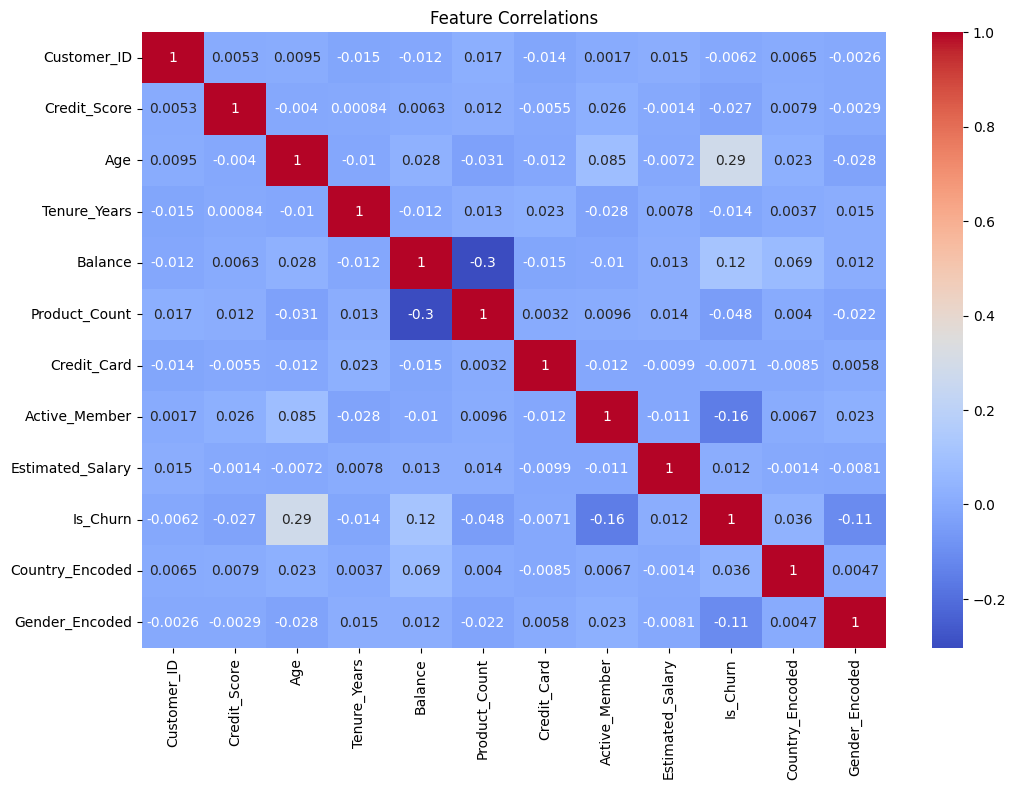

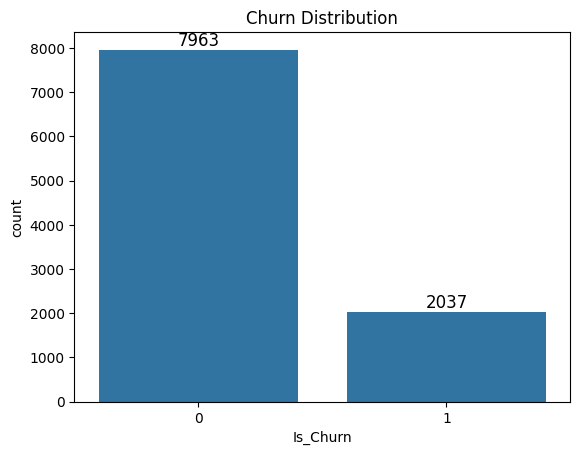

<Figure size 1400x1000 with 0 Axes>

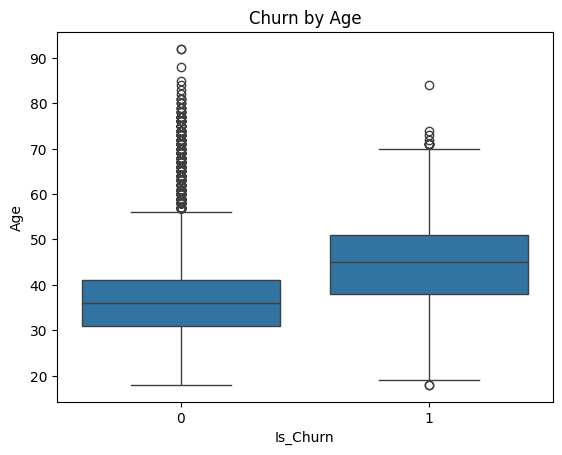

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Heatmap
corr_matrix = churn_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

# Churn distribution
ax = sns.countplot(data=churn_df, x='Is_Churn')
plt.title('Churn Distribution')
plt.figure(figsize=(14, 10))
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=12)
plt.show()


# Churn by Age
sns.boxplot(data=churn_df, x='Is_Churn', y='Age')
plt.title('Churn by Age')
plt.show()




# 4. Model Training

In [77]:
from sklearn.model_selection import train_test_split

X = churn_df.drop(['Is_Churn', 'Customer_ID'], axis=1)
y = churn_df['Is_Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Train a Model 1: Logistic Regression

In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[1565   42]
 [ 322   71]]
              precision    recall  f1-score   support

           0       0.83      0.97      0.90      1607
           1       0.63      0.18      0.28       393

    accuracy                           0.82      2000
   macro avg       0.73      0.58      0.59      2000
weighted avg       0.79      0.82      0.77      2000



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


The Logistic Regression Model perform poorly in predicting churn F1-score of 0.28 for churn confirms this — it’s too low for business use (ideally > 0.6).

Train a Model 2 : Random Forest

In [82]:
from sklearn.metrics import classification_report, confusion_matrix

# Train the Random Forest model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[1558   49]
 [ 218  175]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.78      0.45      0.57       393

    accuracy                           0.87      2000
   macro avg       0.83      0.71      0.74      2000
weighted avg       0.86      0.87      0.85      2000



The Random Forest Model perform poorly in predicting churn F1-score of 0.57 for churn confirms this — it’s too low for business use (ideally > 0.6).

Train a Model 3 : XGBoost

In [83]:
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the model with scale_pos_weight to handle imbalance
xgb_model = XGBClassifier(scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
                          use_label_encoder=False,
                          eval_metric='logloss',
                          random_state=42)

# Fit the model
xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [23:25:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[[1400  207]
 [ 136  257]]
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1607
           1       0.55      0.65      0.60       393

    accuracy                           0.83      2000
   macro avg       0.73      0.76      0.75      2000
weighted avg       0.84      0.83      0.83      2000



Train a Model 4 : CatBoost


In [86]:
!pip install catboost

from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    eval_metric='F1',
    random_seed=42,
    verbose=100,
    class_weights=[1, len(y_train[y_train == 0]) / len(y_train[y_train == 1])]
)

cat_model.fit(X_train, y_train)

y_pred = cat_model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


0:	learn: 0.7317664	total: 3.88ms	remaining: 1.94s
100:	learn: 0.8228494	total: 401ms	remaining: 1.58s
200:	learn: 0.8692411	total: 808ms	remaining: 1.2s
300:	learn: 0.9058817	total: 1.25s	remaining: 825ms
400:	learn: 0.9305789	total: 1.67s	remaining: 413ms
499:	learn: 0.9479166	total: 2.13s	remaining: 0us
[[1408  199]
 [ 124  269]]
              precision    recall  f1-score   support

           0       0.92      0.88      0.90      1607
           1       0.57      0.68      0.62       393

    accuracy                           0.84      2000
   macro avg       0.75      0.78      0.76      2000
weighted avg       0.85      0.84      0.84      2000



Train a Model 5 : CatBoost V.2 Adjusted iteration from 500 to 1000

In [90]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Calculate class weights for imbalance
class_weights = [1, len(y_train[y_train == 0]) / len(y_train[y_train == 1])]

# Initialize the model with improved parameters
cat_model = CatBoostClassifier(
    iterations=1000,                 # More iterations for better learning
    learning_rate=0.05,             # Lower learning rate for smoother convergence
    depth=6,                       # You can experiment with 6-8 for depth
    eval_metric='F1',              # Focus on F1 score
    random_seed=42,
    verbose=100,
    class_weights=class_weights,
    early_stopping_rounds=50,       # Stops if no improvement in 50 rounds
    task_type='CPU',                # Or 'GPU' if you have GPU support
    od_type='Iter'                  # Overfitting detector type
)

# Fit the model and use validation data to enable early stopping
cat_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True             # Use the best model found during training
)

# Predict on test data
y_pred = cat_model.predict(X_test)

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


0:	learn: 0.7317664	test: 0.7233614	best: 0.7233614 (0)	total: 7.44ms	remaining: 7.44s
100:	learn: 0.7972441	test: 0.7912168	best: 0.7917200 (85)	total: 1.45s	remaining: 12.9s
200:	learn: 0.8214014	test: 0.7889110	best: 0.7985470 (154)	total: 3.42s	remaining: 13.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7985470032
bestIteration = 154

Shrink model to first 155 iterations.
[[1329  278]
 [  84  309]]
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      1607
           1       0.53      0.79      0.63       393

    accuracy                           0.82      2000
   macro avg       0.73      0.81      0.76      2000
weighted avg       0.86      0.82      0.83      2000



Train a Model 6 : CatBoost V.3 Test Different thresholds

In [91]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Get predicted probabilities for the positive class
y_pred_prob = cat_model.predict_proba(X_test)[:, 1]

# Test different thresholds
thresholds = np.arange(0.1, 0.9, 0.1)

for thresh in thresholds:
    y_pred_thresh = (y_pred_prob >= thresh).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_thresh, average='binary')
    print(f"Threshold: {thresh:.2f} — Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")


Threshold: 0.10 — Precision: 0.232, Recall: 0.987, F1: 0.376
Threshold: 0.20 — Precision: 0.288, Recall: 0.944, F1: 0.442
Threshold: 0.30 — Precision: 0.350, Recall: 0.893, F1: 0.503
Threshold: 0.40 — Precision: 0.423, Recall: 0.827, F1: 0.559
Threshold: 0.50 — Precision: 0.526, Recall: 0.786, F1: 0.631
Threshold: 0.60 — Precision: 0.614, Recall: 0.687, F1: 0.648
Threshold: 0.70 — Precision: 0.680, Recall: 0.583, F1: 0.627
Threshold: 0.80 — Precision: 0.784, Recall: 0.443, F1: 0.566


In [93]:
best_threshold = 0.55
y_pred_custom = (y_pred_prob >= best_threshold).astype(int)

from sklearn.metrics import classification_report
print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))


[[1388  219]
 [ 100  293]]
              precision    recall  f1-score   support

           0       0.93      0.86      0.90      1607
           1       0.57      0.75      0.65       393

    accuracy                           0.84      2000
   macro avg       0.75      0.80      0.77      2000
weighted avg       0.86      0.84      0.85      2000

